# Notebook 11 v2 — Reference Anchoring & Biological Calibration

## Goal

Notebook11 v2 upgrades the first reference anchoring notebook.

Notebook11 v1 checked whether final simulated outputs stayed inside broad biologically plausible ranges.

Notebook11 v2 adds a more structured calibration framework:

1. A reference table separated from notebook logic
2. Range-based plausibility checking
3. Normalized distance from reference midpoint
4. Metric-level calibration category
5. Generator tuning recommendations

## Important interpretation

This notebook is currently **reference-informed**, not fully **NISTCHO-derived**.

That means the reference ranges are inspired by CHO/NISTCHO literature and expected CHO biologics behavior, but they are not yet extracted directly from raw NISTCHO experimental datasets.

Future versions should replace these manually curated ranges with empirical NISTCHO mean, standard deviation, and percentile distributions.

In [1]:
# --------------------------------------------------
# Section 1 — Imports and load inputs
# --------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    start = Path(start).resolve()

    for p in [start, *start.parents]:
        if (p / "data" / "synthetic").exists():
            return p

    raise FileNotFoundError("Could not find project root containing data/synthetic")


ROOT = find_project_root()

scenario = "legacy"
n_clones = 5000

PARETO_PATH = (
    ROOT / "data" / "synthetic" / "pareto" /
    f"notebook10_final_pareto_recommendations_{n_clones}_{scenario}.csv"
)

QUALITY_PATH = (
    ROOT / "data" / "synthetic" / "quality" /
    f"notebook09_quality_simulation_{n_clones}_{scenario}.csv"
)

LATENT_PATH = (
    ROOT / "data" / "synthetic" / "raw" /
    f"clone_latent_truths_{n_clones}_{scenario}.csv"
)

print("ROOT:", ROOT)
print("PARETO_PATH:", PARETO_PATH)
print("QUALITY_PATH:", QUALITY_PATH)
print("LATENT_PATH:", LATENT_PATH)

pareto_df = pd.read_csv(PARETO_PATH)
quality_df = pd.read_csv(QUALITY_PATH)
latents = pd.read_csv(LATENT_PATH)

print("pareto_df:", pareto_df.shape)
print("quality_df:", quality_df.shape)
print("latents:", latents.shape)

display(pareto_df.head())
display(quality_df.head())
display(latents.head())

ROOT: /Users/sang/CLD_ML_PIPELINE
PARETO_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/pareto/notebook10_final_pareto_recommendations_5000_legacy.csv
QUALITY_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/quality/notebook09_quality_simulation_5000_legacy.csv
LATENT_PATH: /Users/sang/CLD_ML_PIPELINE/data/synthetic/raw/clone_latent_truths_5000_legacy.csv
pareto_df: (92, 18)
quality_df: (8000, 31)
latents: (5000, 33)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,pred_late_qp,pred_qp_drop,pred_late_agg,process_quality_score,quality_pass,pred_rescue_label,pred_rescue_score,recommendation
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,5.537450e-06,0.357910,8.834887,0.471150,True,1,1.000000,Rescue-value Pareto candidate; consider proces...
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,4.417263e-06,0.452348,10.140637,0.358650,True,1,0.776958,Balanced Pareto candidate; strong overall trad...
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,8.950082e-08,0.363346,4.486685,1.403792,True,0,0.388383,Low-risk Pareto candidate; useful for conserva...
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,8.950082e-08,0.363346,4.486685,1.415354,True,0,0.388383,Quality-led Pareto candidate; useful when prod...
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,2.723450e-08,0.247811,6.409449,1.210689,True,0,0.264918,Stability-led Pareto candidate; useful for lon...


,clone_id,process_condition,baseline_quality_score,process_quality_score,quality_score_gain,glycan_maturity,process_glycan_maturity,galactosylation_level,process_galactosylation_level,sialylation_capacity,...,pred_late_agg,pred_rescue_score,pred_rescue_label,is_aggressive,is_super,quality_pass,quality_risk_flag,production_score,combined_quality_utility,combined_quality_utility_guarded
0,CLONE_1502,baseline,0.926955,0.926955,0.000000,0.960779,0.960779,0.672009,0.672009,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.099612,-0.099612
1,CLONE_1502,rich_media,0.926955,0.881629,-0.045326,0.960779,0.968112,0.672009,0.700880,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.117743,-0.117743
2,CLONE_1502,balanced_feed,0.926955,1.092353,0.165398,0.960779,1.000000,0.672009,0.712253,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.033453,-0.033453
3,CLONE_1502,nutrient_limited,0.926955,1.038956,0.112001,0.960779,0.985033,0.672009,0.663833,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.054812,-0.054812
4,CLONE_1502,mild_temp_shift,0.926955,1.115908,0.188953,0.960779,1.000000,0.672009,0.696539,0.777812,...,9.583127,0.598822,1,0,0,True,PASS,-0.783991,-0.024031,-0.024031


,clone_id,productivity,stability,quality_potential,G_platform,platform_group,CN_true,CN_obs,k_decay_i,is_super,...,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,glycan_maturity,galactosylation_level,sialylation_capacity,mannose_retention_risk,aggregation_propensity,product_quality_consistency
0,CLONE_0001,124.997447,0.538616,0.744077,0.439489,0,4,4,0.046569,0,...,0.796684,0.673384,0.641011,0.665561,0.510380,0.474859,0.712412,0.351708,0.517492,0.927489
1,CLONE_0002,33.211918,0.589661,0.690279,0.266919,0,2,2,0.041989,0,...,0.363707,0.720059,0.135232,0.512033,0.726037,0.873543,0.769229,0.384423,0.422744,0.776842
2,CLONE_0003,202.192272,0.589914,0.931177,0.518985,0,5,5,0.070121,0,...,0.797512,0.567776,0.835971,0.563885,0.677784,0.641572,0.835368,0.246703,0.399638,0.598556
3,CLONE_0004,50.943834,0.594953,0.956343,0.638136,0,4,4,0.041947,0,...,0.214300,0.573670,0.484414,0.449087,0.701004,0.885609,0.909993,0.305757,0.268689,0.751828
4,CLONE_0005,126.141664,0.634075,0.897775,0.805367,0,6,6,0.052817,0,...,0.459047,0.611617,0.768044,0.641787,0.879994,0.682306,0.706165,0.113121,0.544114,0.883391


## Section 2 — Merge final pipeline outputs

This section combines:

- Notebook10 Pareto recommendation output
- Notebook09 quality simulation output
- generator latent truth table

The resulting dataframe represents the final candidate set evaluated by:

- productivity
- stability
- process condition
- glycosylation quality
- product quality consistency
- Pareto optimization

In [2]:
# --------------------------------------------------
# Section 2 — Merge final outputs
# --------------------------------------------------

final_df = (
    pareto_df
    .merge(
        quality_df,
        on=["clone_id", "process_condition"],
        how="left",
        suffixes=("_pareto", "_quality")
    )
    .merge(
        latents,
        on="clone_id",
        how="left",
        suffixes=("", "_latent")
    )
)

print("final_df:", final_df.shape)

display(final_df.head())

final_df: (92, 79)


,clone_id,process_condition,pareto_rank,candidate_archetype,weighted_multiobj_score,obj_productivity,obj_stability,obj_quality,obj_risk_safety,obj_rescue_value,...,temperature_shift_responsiveness,feed_responsiveness,secretion_burden_index,process_risk_sensitivity,glycan_maturity_latent,galactosylation_level_latent,sialylation_capacity_latent,mannose_retention_risk_latent,aggregation_propensity_latent,product_quality_consistency_latent
0,CLONE_4625,stress_minimized,1.0,Rescue-value,0.832599,1.000000,0.830653,0.698502,0.612287,1.000000,...,0.638964,0.454035,0.803980,0.225237,0.994772,0.752843,0.626050,0.439776,0.655496,0.815264
1,CLONE_4878,stress_minimized,2.0,Balanced,0.730900,0.796817,0.692042,0.663813,0.731984,0.776958,...,0.592410,0.579437,0.603617,0.391874,1.000000,0.600017,0.436545,0.126983,0.664990,0.493567
2,CLONE_3895,mild_temp_shift,3.0,Risk-safe,0.603442,0.011834,0.822675,0.986077,1.000000,0.388383,...,0.582343,0.638572,0.296905,0.415043,1.000000,0.811800,1.000000,0.000000,0.018254,0.627405
3,CLONE_3895,balanced_feed,4.0,Quality-led,0.601918,0.011834,0.822675,0.989642,0.983893,0.388383,...,0.582343,0.638572,0.296905,0.415043,1.000000,0.811800,1.000000,0.000000,0.018254,0.627405
4,CLONE_3007,stress_minimized,5.0,Stability-led,0.601847,0.000540,0.992249,0.926534,0.967398,0.264918,...,0.366813,0.397037,0.000000,0.444011,0.890684,0.704501,0.882312,0.133496,0.051812,0.898508


## Section 3 — Resolve active column names

Because Notebook09 and Notebook10 outputs share some columns, merge operations may add suffixes.

This helper section identifies the correct active columns for calibration.

This makes Notebook11 more robust to small schema changes.

In [3]:
# --------------------------------------------------
# Section 3 — Robust column resolver
# --------------------------------------------------

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c

    if required:
        raise KeyError(
            f"None of these columns were found: {candidates}\n"
            f"Available columns include:\n{df.columns.tolist()}"
        )

    return None


COLS = {
    "late_productivity_proxy": pick_col(
        final_df,
        ["pred_late_qp", "pred_late_qp_pareto", "pred_late_qp_quality"]
    ),

    "late_aggregation": pick_col(
        final_df,
        ["pred_late_agg", "pred_late_agg_pareto", "pred_late_agg_quality"]
    ),

    "stability_drop": pick_col(
        final_df,
        ["pred_qp_drop", "pred_qp_drop_pareto", "pred_qp_drop_quality"]
    ),

    "mannose_retention_risk": pick_col(
        final_df,
        [
            "process_mannose_retention_risk",
            "process_mannose_retention_risk_quality",
            "mannose_retention_risk",
        ]
    ),

    "galactosylation_level": pick_col(
        final_df,
        [
            "process_galactosylation_level",
            "process_galactosylation_level_quality",
            "galactosylation_level",
        ]
    ),

    "sialylation_capacity": pick_col(
        final_df,
        [
            "process_sialylation_capacity",
            "process_sialylation_capacity_quality",
            "sialylation_capacity",
        ]
    ),

    "aggregation_propensity": pick_col(
        final_df,
        [
            "process_aggregation_propensity",
            "process_aggregation_propensity_quality",
            "aggregation_propensity",
        ],
        required=False
    ),

    "quality_consistency": pick_col(
        final_df,
        [
            "process_quality_consistency",
            "process_quality_consistency_quality",
            "product_quality_consistency",
        ],
        required=False
    ),
}

print("Resolved columns:")
for k, v in COLS.items():
    print(f"{k}: {v}")

Resolved columns:
late_productivity_proxy: pred_late_qp_pareto
late_aggregation: pred_late_agg_pareto
stability_drop: pred_qp_drop_pareto
mannose_retention_risk: process_mannose_retention_risk
galactosylation_level: process_galactosylation_level
sialylation_capacity: process_sialylation_capacity
aggregation_propensity: process_aggregation_propensity
quality_consistency: process_quality_consistency


## Section 4 — Create or load reference anchor table

This section creates a structured reference table.

For v2, the values are manually curated reference-informed ranges.

Later, this table should be replaced or supplemented by empirical NISTCHO-derived distributions.

The table is saved to:

`data/reference/nistcho_reference_ranges_v1.csv`

so the reference assumptions are separated from notebook logic.

In [4]:
# --------------------------------------------------
# Section 4 — Create/load reference anchor table
# --------------------------------------------------

REFERENCE_DIR = ROOT / "data" / "reference"
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_PATH = REFERENCE_DIR / "nistcho_reference_ranges_v1.csv"

if REFERENCE_PATH.exists():
    reference_table = pd.read_csv(REFERENCE_PATH)
    print("Loaded existing reference table:", REFERENCE_PATH)

else:
    reference_table = pd.DataFrame([
        {
            "metric": "late_productivity_proxy",
            "lower_bound": 0.0,
            "upper_bound": 10.0,
            "expected_direction": "higher_is_better",
            "source_type": "reference-informed",
            "notes": "qP-like late productivity proxy; not direct g/L titer."
        },
        {
            "metric": "late_aggregation",
            "lower_bound": 1.0,
            "upper_bound": 15.0,
            "expected_direction": "lower_is_better",
            "source_type": "reference-informed",
            "notes": "Predicted late aggregation plausibility range."
        },
        {
            "metric": "stability_drop",
            "lower_bound": 0.0,
            "upper_bound": 0.70,
            "expected_direction": "lower_is_better",
            "source_type": "reference-informed",
            "notes": "Late productivity decline fraction."
        },
        {
            "metric": "mannose_retention_risk",
            "lower_bound": 0.05,
            "upper_bound": 0.60,
            "expected_direction": "lower_is_better",
            "source_type": "reference-informed",
            "notes": "Normalized high-mannose-like risk."
        },
        {
            "metric": "galactosylation_level",
            "lower_bound": 0.20,
            "upper_bound": 0.80,
            "expected_direction": "target_range",
            "source_type": "reference-informed",
            "notes": "Normalized terminal galactosylation tendency."
        },
        {
            "metric": "sialylation_capacity",
            "lower_bound": 0.05,
            "upper_bound": 0.70,
            "expected_direction": "target_range",
            "source_type": "reference-informed",
            "notes": "Normalized sialylation capacity."
        },
        {
            "metric": "aggregation_propensity",
            "lower_bound": 0.00,
            "upper_bound": 0.70,
            "expected_direction": "lower_is_better",
            "source_type": "reference-informed",
            "notes": "Latent aggregation tendency after process simulation."
        },
        {
            "metric": "quality_consistency",
            "lower_bound": 0.50,
            "upper_bound": 1.00,
            "expected_direction": "higher_is_better",
            "source_type": "reference-informed",
            "notes": "Latent product-quality robustness."
        },
    ])

    reference_table.to_csv(REFERENCE_PATH, index=False)
    print("Created reference table:", REFERENCE_PATH)

reference_table["reference_midpoint"] = (
    reference_table["lower_bound"] + reference_table["upper_bound"]
) / 2

reference_table["reference_width"] = (
    reference_table["upper_bound"] - reference_table["lower_bound"]
)

display(reference_table)

Created reference table: /Users/sang/CLD_ML_PIPELINE/data/reference/nistcho_reference_ranges_v1.csv


,metric,lower_bound,upper_bound,expected_direction,source_type,notes,reference_midpoint,reference_width
0,late_productivity_proxy,0.00,10.0,higher_is_better,reference-informed,qP-like late productivity proxy; not direct g/...,5.000,10.00
1,late_aggregation,1.00,15.0,lower_is_better,reference-informed,Predicted late aggregation plausibility range.,8.000,14.00
2,stability_drop,0.00,0.7,lower_is_better,reference-informed,Late productivity decline fraction.,0.350,0.70
3,mannose_retention_risk,0.05,0.6,lower_is_better,reference-informed,Normalized high-mannose-like risk.,0.325,0.55
4,galactosylation_level,0.20,0.8,target_range,reference-informed,Normalized terminal galactosylation tendency.,0.500,0.60
5,sialylation_capacity,0.05,0.7,target_range,reference-informed,Normalized sialylation capacity.,0.375,0.65
6,aggregation_propensity,0.00,0.7,lower_is_better,reference-informed,Latent aggregation tendency after process simu...,0.350,0.70
7,quality_consistency,0.50,1.0,higher_is_better,reference-informed,Latent product-quality robustness.,0.750,0.50


## Section 5 — Reference alignment scorecard

This section compares final optimized candidates against the reference table.

For each metric, it calculates:

- mean
- standard deviation
- min and max
- percentage inside reference range
- normalized distance from reference midpoint

The normalized distance is useful because it tells us not only whether values are inside the range, but also how centered or drifted they are.

In [5]:
# --------------------------------------------------
# Section 5 — Reference alignment scorecard
# --------------------------------------------------

validation_rows = []

for _, ref in reference_table.iterrows():

    metric = ref["metric"]

    if metric not in COLS:
        continue

    col = COLS[metric]

    if col is None:
        continue

    series = pd.to_numeric(final_df[col], errors="coerce").dropna()

    low = ref["lower_bound"]
    high = ref["upper_bound"]
    midpoint = ref["reference_midpoint"]
    width = ref["reference_width"]

    inside_pct = ((series >= low) & (series <= high)).mean()

    normalized_distance = abs(series.mean() - midpoint) / (width / 2 + 1e-12)

    validation_rows.append({
        "metric": metric,
        "active_column": col,
        "source_type": ref["source_type"],
        "expected_direction": ref["expected_direction"],
        "lower_bound": low,
        "upper_bound": high,
        "reference_midpoint": midpoint,
        "mean": series.mean(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max(),
        "inside_reference_pct": inside_pct,
        "normalized_distance_from_midpoint": normalized_distance,
        "notes": ref["notes"],
    })

alignment_scorecard = pd.DataFrame(validation_rows)

display(alignment_scorecard)

,metric,active_column,source_type,expected_direction,lower_bound,upper_bound,reference_midpoint,mean,std,min,max,inside_reference_pct,normalized_distance_from_midpoint,notes
0,late_productivity_proxy,pred_late_qp_pareto,reference-informed,higher_is_better,0.00,10.0,5.000,3.727049e-07,7.524082e-07,2.498445e-08,0.000006,1.000000,1.000000,qP-like late productivity proxy; not direct g/...
1,late_aggregation,pred_late_agg_pareto,reference-informed,lower_is_better,1.00,15.0,8.000,6.439488e+00,2.380712e+00,2.609595e+00,11.341511,1.000000,0.222930,Predicted late aggregation plausibility range.
2,stability_drop,pred_qp_drop_pareto,reference-informed,lower_is_better,0.00,0.7,0.350,3.609521e-01,6.655213e-02,2.425305e-01,0.624919,1.000000,0.031292,Late productivity decline fraction.
3,mannose_retention_risk,process_mannose_retention_risk,reference-informed,lower_is_better,0.05,0.6,0.325,1.419809e-01,1.409466e-01,0.000000e+00,0.530047,0.630435,0.665524,Normalized high-mannose-like risk.
4,galactosylation_level,process_galactosylation_level,reference-informed,target_range,0.20,0.8,0.500,7.057083e-01,1.862753e-01,2.504851e-01,1.000000,0.663043,0.685694,Normalized terminal galactosylation tendency.
5,sialylation_capacity,process_sialylation_capacity,reference-informed,target_range,0.05,0.7,0.375,6.605190e-01,2.044297e-01,2.880117e-01,1.000000,0.576087,0.878520,Normalized sialylation capacity.
6,aggregation_propensity,process_aggregation_propensity,reference-informed,lower_is_better,0.00,0.7,0.350,2.741770e-01,1.824118e-01,0.000000e+00,0.685919,1.000000,0.216637,Latent aggregation tendency after process simu...
7,quality_consistency,process_quality_consistency,reference-informed,higher_is_better,0.50,1.0,0.750,8.079162e-01,1.617616e-01,5.094988e-01,1.000000,1.000000,0.231665,Latent product-quality robustness.


## Section 6 — Calibration category assignment

This section converts numeric alignment results into interpretation categories.

The categories are:

- Excellent
- Acceptable
- Borderline
- Needs tuning

This makes the calibration output easier to interpret and easier to discuss.

In [6]:
# --------------------------------------------------
# Section 6 — Calibration category assignment
# --------------------------------------------------

def assign_calibration_category(row):
    inside = row["inside_reference_pct"]
    distance = row["normalized_distance_from_midpoint"]

    if inside >= 0.95 and distance <= 0.50:
        return "Excellent"

    if inside >= 0.90 and distance <= 0.80:
        return "Acceptable"

    if inside >= 0.80:
        return "Borderline"

    return "Needs tuning"


alignment_scorecard["calibration_category"] = alignment_scorecard.apply(
    assign_calibration_category,
    axis=1,
)

alignment_scorecard["calibration_score"] = (
    100 * alignment_scorecard["inside_reference_pct"]
    * (1 / (1 + alignment_scorecard["normalized_distance_from_midpoint"]))
)

overall_calibration_score = alignment_scorecard["calibration_score"].mean()

print("Overall calibration score:", round(overall_calibration_score, 2))

display(
    alignment_scorecard[
        [
            "metric",
            "active_column",
            "inside_reference_pct",
            "normalized_distance_from_midpoint",
            "calibration_score",
            "calibration_category",
            "notes",
        ]
    ]
)

Overall calibration score: 62.5


,metric,active_column,inside_reference_pct,normalized_distance_from_midpoint,calibration_score,calibration_category,notes
0,late_productivity_proxy,pred_late_qp_pareto,1.000000,1.000000,50.000002,Borderline,qP-like late productivity proxy; not direct g/...
1,late_aggregation,pred_late_agg_pareto,1.000000,0.222930,81.770810,Excellent,Predicted late aggregation plausibility range.
2,stability_drop,pred_qp_drop_pareto,1.000000,0.031292,96.965782,Excellent,Late productivity decline fraction.
3,mannose_retention_risk,process_mannose_retention_risk,0.630435,0.665524,37.852040,Needs tuning,Normalized high-mannose-like risk.
4,galactosylation_level,process_galactosylation_level,0.663043,0.685694,39.333551,Needs tuning,Normalized terminal galactosylation tendency.
5,sialylation_capacity,process_sialylation_capacity,0.576087,0.878520,30.667066,Needs tuning,Normalized sialylation capacity.
6,aggregation_propensity,process_aggregation_propensity,1.000000,0.216637,82.193774,Excellent,Latent aggregation tendency after process simu...
7,quality_consistency,process_quality_consistency,1.000000,0.231665,81.190924,Excellent,Latent product-quality robustness.


## Section 7 — Reference drift analysis

This section checks whether each metric tends to drift below or above its reference range.

This helps identify which simulator assumptions may need tuning.

Examples:

- high aggregation drift may suggest excessive stress or aggregation propensity
- high mannose drift may suggest too much process risk or too little glycan maturity
- low galactosylation drift may suggest weak feed/glycan coupling

In [7]:
# --------------------------------------------------
# Section 7 — Reference drift analysis
# --------------------------------------------------

drift_rows = []

for _, ref in reference_table.iterrows():

    metric = ref["metric"]

    if metric not in COLS:
        continue

    col = COLS[metric]

    if col is None:
        continue

    series = pd.to_numeric(final_df[col], errors="coerce").dropna()

    low = ref["lower_bound"]
    high = ref["upper_bound"]

    drift_rows.append({
        "metric": metric,
        "active_column": col,
        "below_reference_pct": (series < low).mean(),
        "above_reference_pct": (series > high).mean(),
        "mean": series.mean(),
        "lower_bound": low,
        "upper_bound": high,
    })

drift_df = pd.DataFrame(drift_rows)

display(drift_df)

,metric,active_column,below_reference_pct,above_reference_pct,mean,lower_bound,upper_bound
0,late_productivity_proxy,pred_late_qp_pareto,0.000000,0.000000,3.727049e-07,0.00,10.0
1,late_aggregation,pred_late_agg_pareto,0.000000,0.000000,6.439488e+00,1.00,15.0
2,stability_drop,pred_qp_drop_pareto,0.000000,0.000000,3.609521e-01,0.00,0.7
3,mannose_retention_risk,process_mannose_retention_risk,0.369565,0.000000,1.419809e-01,0.05,0.6
4,galactosylation_level,process_galactosylation_level,0.000000,0.336957,7.057083e-01,0.20,0.8
5,sialylation_capacity,process_sialylation_capacity,0.000000,0.423913,6.605190e-01,0.05,0.7
6,aggregation_propensity,process_aggregation_propensity,0.000000,0.000000,2.741770e-01,0.00,0.7
7,quality_consistency,process_quality_consistency,0.000000,0.000000,8.079162e-01,0.50,1.0


## Section 8 — Generator tuning recommendation table

This section translates calibration drift into practical generator tuning suggestions.

The purpose is to make Notebook11 actionable.

Instead of only saying whether the simulator is realistic, it recommends which generator knobs may need adjustment.

In [8]:
# --------------------------------------------------
# Section 8 — Generator tuning recommendation table
# --------------------------------------------------

def tuning_recommendation(row):
    metric = row["metric"]
    below = row["below_reference_pct"]
    above = row["above_reference_pct"]

    if metric == "late_productivity_proxy":
        if above > 0.10:
            return "Reduce productivity scaling or process titer_gain assumptions."
        if below > 0.10:
            return "Increase alpha_titer, productivity latent mean, or process gain."
        return "No major productivity tuning needed."

    if metric == "late_aggregation":
        if above > 0.10:
            return "Reduce aggregation stress effects or aggregation_propensity_risk_weight."
        if below > 0.10:
            return "Increase aggregation realism or late aggregation noise."
        return "Aggregation range appears acceptable."

    if metric == "stability_drop":
        if above > 0.10:
            return "Reduce k_decay, aggressive_late_extra_decay, or hidden late titer noise."
        if below > 0.10:
            return "Increase late instability or clone-specific decay variation."
        return "Stability drop range appears acceptable."

    if metric == "mannose_retention_risk":
        if above > 0.10:
            return "Reduce mannose_risk_process_risk_weight or secretion_burden effect."
        if below > 0.10:
            return "Increase high-mannose risk coupling under stress/process burden."
        return "Mannose retention risk appears acceptable."

    if metric == "galactosylation_level":
        if above > 0.10:
            return "Reduce galactosylation_maturity_weight or feed responsiveness effect."
        if below > 0.10:
            return "Increase glycan maturity/feed coupling for galactosylation."
        return "Galactosylation range appears acceptable."

    if metric == "sialylation_capacity":
        if above > 0.10:
            return "Reduce sialylation maturity/stress adaptation weights."
        if below > 0.10:
            return "Increase sialylation capacity or reduce process risk penalty."
        return "Sialylation range appears acceptable."

    if metric == "aggregation_propensity":
        if above > 0.10:
            return "Reduce aggregation_propensity_risk_weight or burden coupling."
        if below > 0.10:
            return "Increase aggregation propensity variability."
        return "Aggregation propensity appears acceptable."

    if metric == "quality_consistency":
        if below > 0.10:
            return "Increase quality_consistency_stress_adapt_weight or reduce burden penalty."
        if above > 0.10:
            return "Increase quality inconsistency/noise to avoid over-optimistic quality."
        return "Quality consistency appears acceptable."

    return "No recommendation available."


tuning_table = drift_df.copy()
tuning_table["recommendation"] = tuning_table.apply(
    tuning_recommendation,
    axis=1,
)

display(tuning_table)

,metric,active_column,below_reference_pct,above_reference_pct,mean,lower_bound,upper_bound,recommendation
0,late_productivity_proxy,pred_late_qp_pareto,0.000000,0.000000,3.727049e-07,0.00,10.0,No major productivity tuning needed.
1,late_aggregation,pred_late_agg_pareto,0.000000,0.000000,6.439488e+00,1.00,15.0,Aggregation range appears acceptable.
2,stability_drop,pred_qp_drop_pareto,0.000000,0.000000,3.609521e-01,0.00,0.7,Stability drop range appears acceptable.
3,mannose_retention_risk,process_mannose_retention_risk,0.369565,0.000000,1.419809e-01,0.05,0.6,Increase high-mannose risk coupling under stre...
4,galactosylation_level,process_galactosylation_level,0.000000,0.336957,7.057083e-01,0.20,0.8,Reduce galactosylation_maturity_weight or feed...
5,sialylation_capacity,process_sialylation_capacity,0.000000,0.423913,6.605190e-01,0.05,0.7,Reduce sialylation maturity/stress adaptation ...
6,aggregation_propensity,process_aggregation_propensity,0.000000,0.000000,2.741770e-01,0.00,0.7,Aggregation propensity appears acceptable.
7,quality_consistency,process_quality_consistency,0.000000,0.000000,8.079162e-01,0.50,1.0,Quality consistency appears acceptable.


## Section 9 — Visualization

This section visualizes reference alignment.

Vertical dashed lines indicate the reference-informed lower and upper bounds.

These plots help visually detect whether outputs are centered, shifted, too narrow, or too wide.

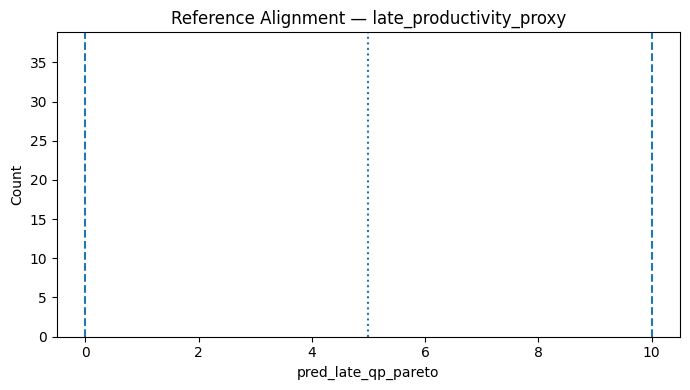

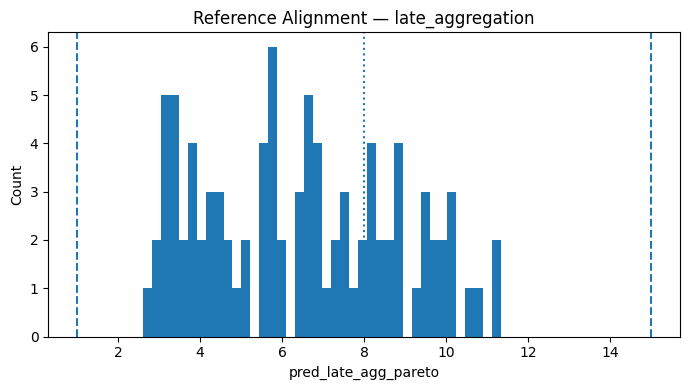

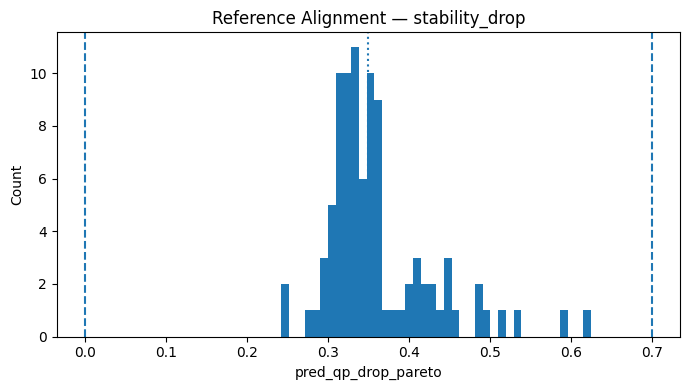

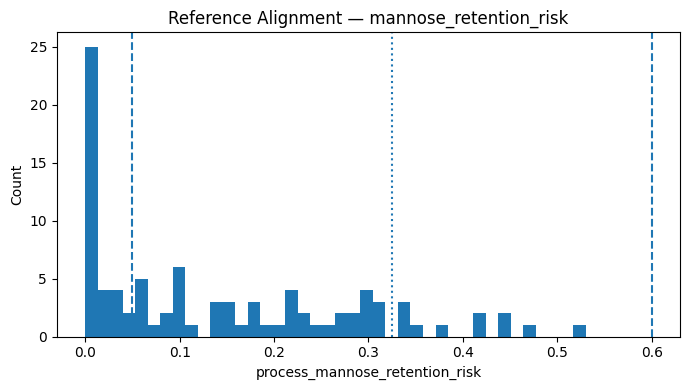

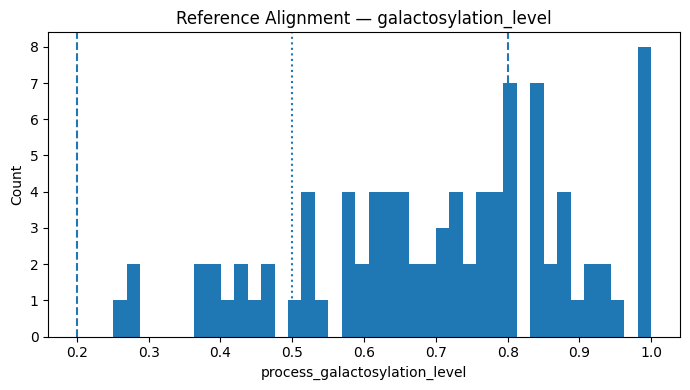

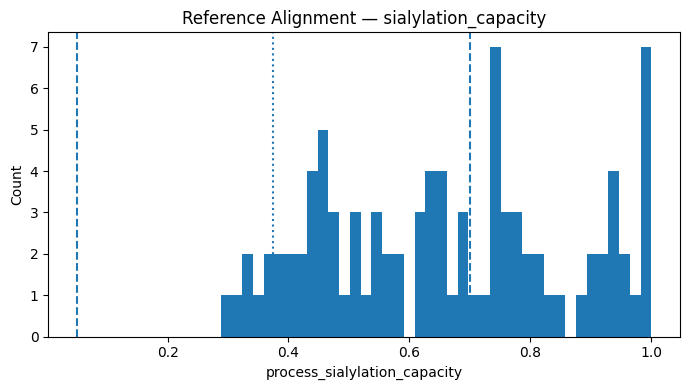

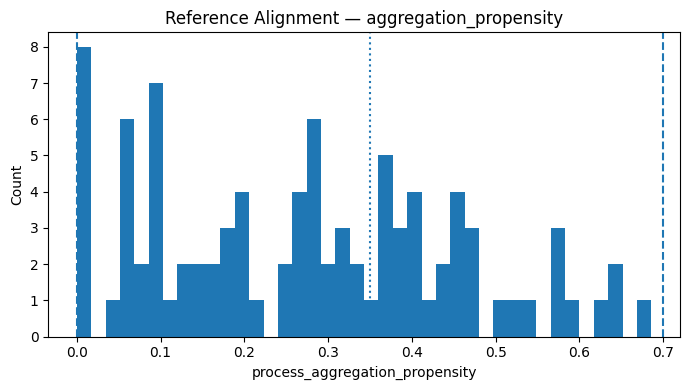

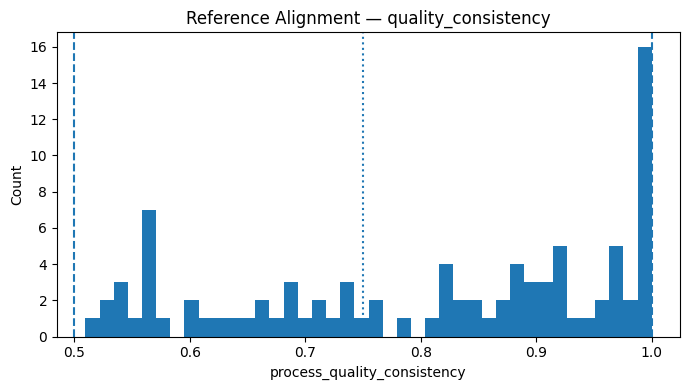

In [9]:
# --------------------------------------------------
# Section 9 — Visualization
# --------------------------------------------------

for _, row in alignment_scorecard.iterrows():

    metric = row["metric"]
    col = row["active_column"]

    series = pd.to_numeric(final_df[col], errors="coerce").dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(series, bins=40)

    plt.axvline(row["lower_bound"], linestyle="--")
    plt.axvline(row["upper_bound"], linestyle="--")
    plt.axvline(row["reference_midpoint"], linestyle=":")

    plt.title(f"Reference Alignment — {metric}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Section 10 — Final biological interpretation

This section summarizes which metrics are well calibrated and which metrics may need generator tuning.

The goal is to make the calibration notebook directly useful for the next simulator update.

In [10]:
# --------------------------------------------------
# Section 10 — Final biological interpretation
# --------------------------------------------------

interpretation_rows = []

for _, row in alignment_scorecard.iterrows():

    metric = row["metric"]
    category = row["calibration_category"]

    if category == "Excellent":
        interpretation = "Strong biological plausibility. No immediate tuning needed."
    elif category == "Acceptable":
        interpretation = "Biologically acceptable. Monitor in future versions."
    elif category == "Borderline":
        interpretation = "Mostly plausible but may need tuning if this metric is strategically important."
    else:
        interpretation = "Potential realism issue. Generator tuning recommended."

    interpretation_rows.append({
        "metric": metric,
        "calibration_category": category,
        "interpretation": interpretation,
    })

interpretation_df = pd.DataFrame(interpretation_rows)

display(interpretation_df)

,metric,calibration_category,interpretation
0,late_productivity_proxy,Borderline,Mostly plausible but may need tuning if this m...
1,late_aggregation,Excellent,Strong biological plausibility. No immediate t...
2,stability_drop,Excellent,Strong biological plausibility. No immediate t...
3,mannose_retention_risk,Needs tuning,Potential realism issue. Generator tuning reco...
4,galactosylation_level,Needs tuning,Potential realism issue. Generator tuning reco...
5,sialylation_capacity,Needs tuning,Potential realism issue. Generator tuning reco...
6,aggregation_propensity,Excellent,Strong biological plausibility. No immediate t...
7,quality_consistency,Excellent,Strong biological plausibility. No immediate t...


## Section 11 — Save outputs

This section saves the Notebook11 v2 calibration outputs.

Outputs are saved to:

`data/synthetic/calibration/`

In [11]:
# --------------------------------------------------
# Section 11 — Save outputs
# --------------------------------------------------

CALIB_DIR = ROOT / "data" / "synthetic" / "calibration"
CALIB_DIR.mkdir(parents=True, exist_ok=True)

alignment_path = CALIB_DIR / f"notebook11v2_reference_alignment_scorecard_{n_clones}_{scenario}.csv"
drift_path = CALIB_DIR / f"notebook11v2_reference_drift_{n_clones}_{scenario}.csv"
tuning_path = CALIB_DIR / f"notebook11v2_tuning_recommendations_{n_clones}_{scenario}.csv"
interpretation_path = CALIB_DIR / f"notebook11v2_interpretation_{n_clones}_{scenario}.csv"

alignment_scorecard.to_csv(alignment_path, index=False)
drift_df.to_csv(drift_path, index=False)
tuning_table.to_csv(tuning_path, index=False)
interpretation_df.to_csv(interpretation_path, index=False)

print("Saved:")
print(alignment_path)
print(drift_path)
print(tuning_path)
print(interpretation_path)

Saved:
/Users/sang/CLD_ML_PIPELINE/data/synthetic/calibration/notebook11v2_reference_alignment_scorecard_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/calibration/notebook11v2_reference_drift_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/calibration/notebook11v2_tuning_recommendations_5000_legacy.csv
/Users/sang/CLD_ML_PIPELINE/data/synthetic/calibration/notebook11v2_interpretation_5000_legacy.csv


# Final Summary — Notebook11 v2

Notebook11 v2 upgrades the biological calibration layer of the CLD simulator.

The key transition is:

```text
simple reference range check
→ structured reference alignment scorecard
```

This notebook evaluates whether final clone × process × quality candidates remain biologically plausible after:

- process optimization
- glycosylation quality simulation
- Pareto optimization
- final recommendation filtering

## What changed from v1

Notebook11 v1 asked:

```text
Are outputs inside broad biological ranges?
```

Notebook11 v2 asks:

```text
How well aligned are outputs with reference-informed CHO/NISTCHO-like ranges?
Which metrics drift?
Which generator knobs should be tuned?
```

## Key outputs

This notebook produces:

- reference alignment scorecard
- reference drift table
- generator tuning recommendation table
- biological interpretation table

## Important interpretation

This notebook is still reference-informed, not fully NISTCHO-derived.

The current ranges are biologically motivated, but they are not yet computed directly from raw NISTCHO experimental datasets.

Therefore, the correct interpretation is:

```text
The simulator is biologically plausibility-anchored.
```

not yet:

```text
The simulator is experimentally validated against NISTCHO.
```

## Strategic meaning

Notebook11 v2 makes the project more defensible.

It turns calibration into an actionable feedback loop:

```text
simulate
→ evaluate biological realism
→ identify drift
→ tune generator
→ rerun pipeline
```

This is an important step toward a realistic CHO CLD/CDMO decision-support simulator.

Future versions should replace manual reference-informed ranges with empirical NISTCHO-derived distributions and multivariate biological distance scoring.